## ***Loading and Preprocessing ***

In [1]:
# Import necessary libraries
from sklearn.datasets import load_iris
import pandas as pd

# Load the Iris dataset
iris = load_iris()

# Convert to a pandas DataFrame (features only)
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Show the first few rows to verify
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### **Clustering Algorithm Implementation - KMeans Clustering**

KMeans Clustering is an unsupervised machine learning algorithm used to group data into K clusters based on feature similarity.

Choose the number of clusters K.

Initialize K centroids randomly.

Assign each data point to the nearest centroid (forming clusters).

Recalculate the centroids by taking the mean of all points in each cluster.

Repeat steps until centroids stop changing significantly (convergence).



### Why KMeans is Suitable for the Iris Dataset

he Iris dataset contains continuous numerical features.

It’s a small, well-structured dataset with visually separable classes.

There are 3 species in the dataset, which aligns well with choosing K=3.

In [2]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)


In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(df)

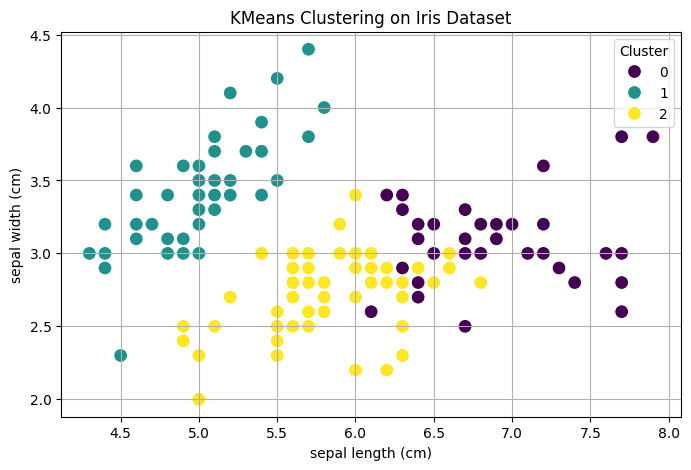

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=df[iris.feature_names[0]],
    y=df[iris.feature_names[1]],
    hue=df['Cluster'],
    palette='viridis',
    s=100
)
plt.title('KMeans Clustering on Iris Dataset')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# ***Hierarchical Clustering***

Hierarchical Clustering is an unsupervised learning technique that builds a hierarchy of clusters. There are two main types:

Agglomerative (bottom-up): Each data point starts as its own cluster, and clusters are merged step-by-step based on similarity.

Divisive (top-down): Starts with one cluster and splits it into smaller ones (less common).

##Steps for Agglomerative Hierarchical Clustering:

Start with each point as its own cluster.

Compute distances (using linkage methods like single, complete, average, ward).

Merge the closest two clusters.

Repeat until all points are in one cluster.

Represent results in a dendrogram.



## Why Hierarchical Clustering

The Iris dataset is small (150 samples), making it efficient to compute hierarchical relationships.

The dataset has visually separable clusters.

Hierarchical clustering doesn’t require specifying K up front — you can choose the number of clusters from the dendrogram.

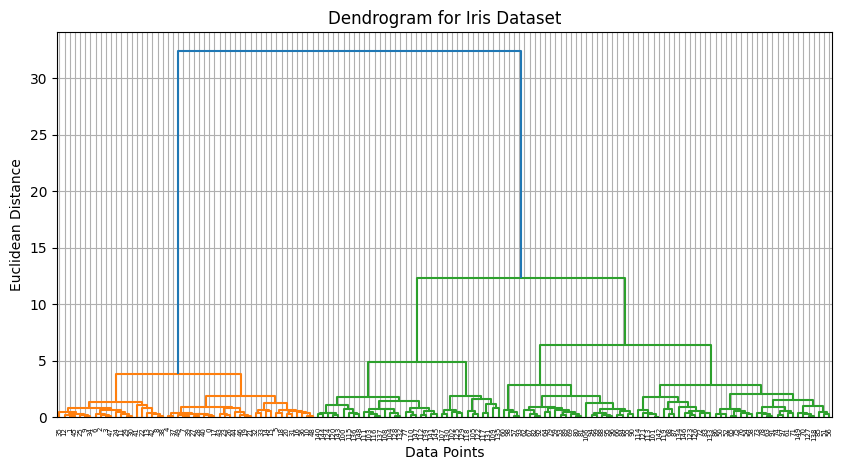

TypeError: AgglomerativeClustering.__init__() got an unexpected keyword argument 'affinity'

In [11]:
# Step 1: Import necessary libraries
from sklearn.datasets import load_iris
import pandas as pd
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load and prepare the Iris dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Step 3: Create dendrogram to visualize hierarchy
plt.figure(figsize=(10, 5))
dendrogram = sch.dendrogram(sch.linkage(df, method='ward'))
plt.title('Dendrogram for Iris Dataset')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')
plt.grid(True)
plt.show()

# Step 4: Apply Agglomerative Hierarchical Clustering
hc = AgglomerativeClustering(n_clusters=3, affinity='euclidean', linkage='ward')
df['Cluster'] = hc.fit_predict(df)

# Step 5: Visualize clusters using 2 features (you can pick different ones too)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=df[iris.feature_names[0]],
    y=df[iris.feature_names[1]],
    hue=df['Cluster'],
    palette='Set1',
    s=100
)
plt.title('Hierarchical Clustering on Iris Dataset')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend(title='Cluster')
plt.grid(True)
plt.show()